# Jump method and quantum trajectory

The quantum master equation  is useful if we are interested in the expectation value of observables.  We are able to calculate $g^{(2)(\tau)$ utilizing the quantum regression theorem.  However, it is not the best way to calculate the full counting statistics.  In this section, we explore an alternative method suitable for counting statistics. The method is known as the jump method in which the system jumps from a state to another and produces quantum trajectories.  It seems that no quantum trajectory of two-level system has been reported, perhaps because the process is too rapid.  Quantum trajectories have been observed in a two-level system with additional staging state where jumps between the excited state and the staging state were clearly seen.{cite:p}`Nagourney1986,Bergquist1986,Sauter1986`  The jump method has been used to simulate the observed quantum trajectories. {cite:p}`Plenio1998`

## A brief summary of the jump method

Here only a brief summary of the jump method is provided. Many textbooks of quantum optics or open quantum systems discuss the details of the method.{cite:p}`Carmichael1993,Plenio1998,Breuer2002,Lambropoulos2007,Meystre2007`  


We begin with the quantum master equation

$$
\frac{d}{dt} \rho = - i [H,\rho] + D(\rho)
$$

where 

$$
D(\rho) = \sum_{i} \left[ C_{i} \rho C_{i}^{\dagger} - \frac{1}{2} \left\{ C_{i}^{\dagger} C_{i}, \rho \right\} \right]
$$

For simplicity, only one index $i$ is used in place of $i$ and $\omega$.  By rearranging the terms, we write the master equation slightly in a different form:

$$
\frac{d}{dt} \rho = -i [H_\text{eff},\rho] + \mathcal{L}_\text{jump}(\rho)
$$

where the effective Hamiltonian is defined by

$$
H_\text{eff} = H - \frac{i}{2} \sum_{i} C^{\dagger}_{i} C_{i}
$$

and the jump Liouvillian by

$$
\mathcal{L}_\text{jump}(\rho) = \sum_{i} C_{i} \rho C^{\dagger}_{i}.
$$

So far we just wrote the same master equation in two different ways.

For now, we ignore $\mathcal{L}_\text{jump}$ and look at $\frac{t}{dt} \rho = -i [H_\text{eff},\rho]$, which resembles the Liouville-von Neumann equation.  The corresponding Schr&ouml;dinger-like equation is

$$
i \frac{d}{dt} |\psi\rangle = H_\text{eff} | \psi\rangle.
$$

This is not exactly Schr&ouml;dinger equation because $H_\text{eff}$ is not self-adjoint, that is $H_\text{eff} \ne H^{\dagger}_\text{eff}$.  Hence, the norm of $|\psi\rangle$ is not conserved.  We know that the master equation does conserve the norm of the density operator ($\text{tr}\rho = 1$).  If we take into account the jump term, the norm must be conserved but it cannot be included directly in the Schr&ouml;dinger-like equation.  We need a mathematical trick to take into account the jump term.  What does the jump term do the the pure state $|\psi\rangle$?   $\mathcal{L}_\text{jump} (|\psi\rangle\langle\psi|) = \sum_i C_{i}|\psi\rangle\langle\psi|C^{\dagger}_{i}$ tells that the the system jump out from $|\psi\rangle$ to $C_{i}|\psi\rangle$, suggesting that the norm of $|psi\rangle$ decreases.  In other words, the system changes in two different ways, smooth change according to the Schr&ouml;dinger equation and jump by the jump operator $C_{i}$. We don't know which one happens.  So, we resort to Monte Carlo method which chose one at random. 

Now, we implement this idea in a mathematical form.  Suppose that the system is in a pure state $|\psi(t)\rangle$ at time $t$ and it is normalized as $\langle\psi(t)|\psi(t)\rangle=1$.  If the system were to evolve for a brief time $\delta t$ according to the  Schr&ouml;dinger equation, the new state is given by

$$
|\psi(t+\delta t)\rangle = \left(1 - i H_\text{eff} \delta t\right) |\psi(t)\rangle
$$(eq:no-jump)

and its norm is

$$
\begin{align}
\langle \psi(t+\delta t)|\psi(t+\delta t)\rangle &= \langle \psi(t)| \big(1 + i H^{\dagger}_\text{eff} \delta t \big) \big(1 - i H_\text{eff} \delta t\big) |\psi(t)\rangle \\
\\
&\approx 1 - \delta p
\end{align}
$$

where the missing norm is tothe lowest order in $\delta t$ given by

$$
\begin{align}
\delta p &\approx i \delta t \langle \psi(t)| H_\text{eff} - H^{\dagger}_\text{eff}|\psi(t)\rangle  \\
&= \delta t \sum_{i} \langle \psi(t)|C_{i}^{\dagger} C_{i}|\psi(t)\rangle  
\end{align}
$$

Clearly $\delta p \ge 0$ and thus the norm is indeed reduced.  If $\delta p = $, then, the norm is conserved and no jump takes place.  On the other hand, if $\delta p =1$, then the norm completely vanishes and one of jump processes takes place.  Therefore, $\delta p$ behaves like a probability of a jump happens.  We introduce a stochastic process based on this probability. Our assumption is that a jump happens with probability $\delta p$.  In practice, we generate a uniform random number $r \in [0,1]$ and if $r>\delta p$ then a jump happens and other wise, the new state {eq}`eq:no-jump` is accepted.  If there are multiple jump channels, we need to pick one channel.  Notice that $\delta n_{i} = \delta t \langle \psi(t)|C_{i}^{\dagger} C_{i}|\psi(t)\rangle$ is the expectation value of $C_{i}^\dagger C_{i}$ which looks like a number operator (it is indeed a number operator in many cases in optics).  $\delta n_{i}$ indicate a likelihood of jump to $C_{i}|\psi\rangle$.  We define the probability that a particular jump happens as $\delta p_{i} = \delta n_{i} /\sum_{i} \delta n_{i} = \delta n_{i}/\delta p $.




## Algorithm


Here is the summary of algorithm.

**Initial preparation**
1.  Set a time step size $\delta t$.  it should be much smaller than the time scale of Hamiltonian and dissipation.
2.  Set initial time $t_0 = 0$ and loop counter $k=0$.
3.  Prepare an initial state $\psi(0)\rangle$ at time $t=0$ at random. It should be normalized.

**Main loop begins**
1. Increment a loop counter: $k=k+1$.
1. Set a new time $t_{k} = t_{k-1}+\delta t$.

**Choose Schr&ouml;dinger step or jump step at random**
1.  Evaluate $\delta n_{i} = \delta t \langle \psi(t_{k-1})|C_{i}^{\dagger} C_{i}|\psi(t_{k-1})\rangle$ for each $i$.
2.  Calculate probabilities $\delta p = \sum_{i} \delta n_{i}$.
3.  Generate a uniform random number $r \in [0,1]$.  If $r > \delta p$, then go to Schr&ouml;dinger step.  Otherwise go to jump step.

**Schr&ouml;dinger step**
1.  Compute a new state $|\psi(t_{k})\rangle = \left( 1 - i H_\text{eff} \delta t \right) |\psi(t_{k-1})\rangle$.
2.  Normalize the new state.
3.  Set jump flag = 0
4.  Go to recording step.


**Jump step**
1.  Generate a uniform random number $r \in [0,1]$.  Pick a jump channel based on the random number. (Find a good method for your application.)
2.  Compute a new state $|\psi(t_{k})\rangle = C_{i} | \psi(t_{k-1} \rangle$.
3.  Normalize the new state.
4.  Set jump flag = channel number
5.  Go to recording step.

**Recording step**
1.  Record current time
2.  Using the new state vector, evaluate expectation value of desired observables.  Record them.
3.  If jump flag > 0, then record jump time
4.  Go to the next cycle of the main loop



## Example:  Two-level system in thermal environment

In {numref}`sec:qme`, we calculated the state of a two-level system using the quantum master equation.  Let us simulate the quantum trajectory of the same system. The following code calculate a quantum trajectory using the algorithm given above.  Only one trajectory is computed and no statistical analysis is done.  Run the code several times. A different trajectory is obtained each time because the process is stochastic.

In the following code, the simulation continues until the photon counts reaches the maximum. It takes a while to complete the simulation if a large number of photons are specified.   At each time step, $\langle \sigma_z \rangle$ is computed and the time a photon is emitted is recorded.

In [1]:
# ignore warnings (qutip issues various unwanted warnings)
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# reset random number
rng = np.random.default_rng()

def schroedinger(H,psi,dt):
    psi_new = (1 - 1j*H*dt) * psi
    return psi_new.unit()

def jump(c_ops,psi,dq):
    r = rng.random()
    if r < dq[0]:
        psi_new = c_ops[0] * psi
        flag=0
    else:
        psi_new = c_ops[1] * psi
        flag=1
    return psi_new.unit(),flag

# System parameters
omega0 = 1.0   # excitation energy
gamma0 = 0.1   # spontaneous emission rate
temperature = 1.0  # tempeature of photon gas
N = 1/(np.exp(omega0/temperature)-1) # Planck distribution

# Collapse operators
n_c_ops = 2
gamma1 = gamma0 * N   # coefficient to absorption
gamma2 = gamma0 * (N+1)  # coefficient to emission
c_ops = [np.sqrt(gamma1) * sigmap(),np.sqrt(gamma2) * sigmam()]
n = np.zeros([len(c_ops),1])
dq = np.zeros([len(c_ops),1])

# Effective Hamiltonian for a two-level system
H = 0.5 * omega0 * sigmaz()
for i in range(len(c_ops)):
    H = H - 0.5j * c_ops[i].dag() * c_ops[i]

# set arrays for record
times = np.array([])   # time
spikes = np.array([])  # time when a photon is emitted
sz = np.array([]) # expectation value of sigma_z

# control parameters
# maximum number of photons to be counted
max_photons = 1000

# time step
dt = 0.1  

# number of photons emitted
n_photons = 0 

# current time
k=0 # loop counter
times = np.append(times,k*dt)

# random initial state vector
theta = rng.random()*2*np.pi
psi = basis(2,0)*np.sin(theta) + basis(2,1)*np.cos(theta)

# we measure sigmaz
sz = np.append(sz,expect(sigmaz(),psi))

# main loop begins
while n_photons < max_photons:

# set new time
    k += 1
    times = np.append(times,k*dt)

# calculate jump probability

    for j in range(len(c_ops)):
       n[j] = expect(c_ops[j].dag() * c_ops[j], psi)*dt
    dp = sum(n)
    dq = n/dp

# choose schraoedinger or jump step at random
    if rng.random() > dp:
        # Srhcoedinger step
        psi_new = schroedinger(H,psi,dt)

    else:
        # Jump step
        psi_new, flag = jump(c_ops,psi,dq)
        if flag == 1:  # emission
            spikes = np.append(spikes,times[k])
            n_photons += 1

# record the expectation value
    sz = np.append(sz,expect(sigmaz(),psi_new))

# set the state vector for next cycle
    psi=psi_new


### Quantum trajectory

First, we plot the quantum trajectory and the spike train of the first 50 photons. Compare the spikes of photon with three statistical types discussed in 

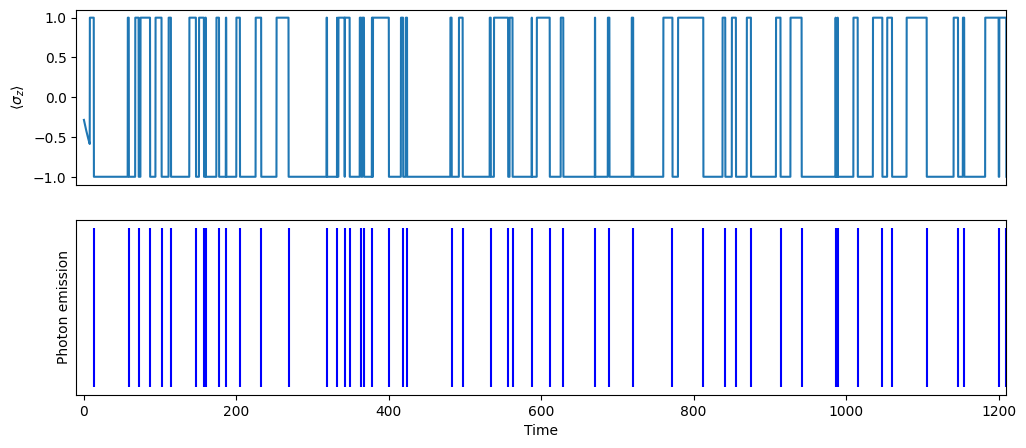

In [2]:
max_time = spikes[50]

plt.figure(figsize=(12, 5))
plt.subplot(2,1,1)
plt.plot(times,sz)
plt.xticks([])
plt.xlim([-10,max_time+10])
plt.ylabel(r"$\langle \sigma_z \rangle$")
plt.subplot(2,1,2)
plt.xlim([-10,max_time+10])
plt.yticks([])
plt.xlabel("Time")
plt.ylabel("Photon emission")
plt.vlines(spikes, 0, 1, color='b', label="emission")
plt.show()

To see what is going on, we write the effective Hamiltonian.

$$
H_\text{eff} = \frac{\omega_0}{2}\left[ \left( 1 - i \frac{\Gamma_{e}}{\omega_0}\right)|e \rangle\langle e| - \left( 1 + i \frac{\Gamma_{a}}{\omega_0}\right)| g \rangle\langle g| \right]
$$

Suppose that the system is in a state $\psi(t) = c_0 |e\rangle + c_1 |g\rangle$.  The Schr&ouml;dinger step generates a new state (see {numref}`sec:qme` for the notations.)

$$
|\psi(t+\delta t)\rangle = c_0 e^{-i \omega_0 \delta t /2}  e^{- \Gamma_e \delta t /2} |e\rangle + c_1 e^{+i \omega_0 \delta t/2} e^{-\Gamma_a \delta t/2} |g\rangle
$$

which indicates that the excited state decays with the decay rate $\Gamma_e/2$ and the ground state with $\Gamma_a/2$.  This is why the norm of state decreases.

If a jump happens, the resulting state is one of the following two:

$$
\psi(t+\delta t) = \begin{cases}
\sqrt{\Gamma_{a}}|e\rangle\langle g|\psi(t)\rangle = \sqrt{\Gamma_{a}} c_1 |e\rangle & \text{jump up}\\
\sqrt{\Gamma_{e}}|g\rangle\langle e|\psi(t)\rangle = \sqrt{\Gamma_{e}} c_0 |g\rangle & \text{jump down}
\end{cases}
$$

Notice that after the jump, the system is either in the ground state or in the excited state.  The Schr&ouml;dinger step does not change the occupation rate.  Hence, only the system can do is to stay either in $|e\rangle$ or $|g\rangle$ or to jump between them. Even if the initial state is a super position state,  the system is either in $|e\rangle$ or $|g\rangle$ after the first jump.  Because of this, we can clearly identify when photons are emitted, and thus we have full counting statistics.  The second plot in the above example shows the times a single photon is emitted.  

The type of counting statistics is not clear from the plot.  We need a waiting time distribution and $g^{(2)}(\tau)$.  However, in order to get accurate statistics, we need far more samplings.  Simply repeat the above simulation and accumulate data.

### Waiting time distribution and statistics

In the above example, we have a very limited sampling.  Nevertheless, we attempt to make a statistical analysis as a practice.  We generate collection of waiting time and evaluate statistical information.  Since the variance is smaller than the mean squared, the distribution is most likely sub-poissonian and thus anti-bunching is expected, in consistent with $g^{(2)}(\tau)$ obtained by the quantum master equation.


mean waiting time  =  23.993993993993993
standard deviation =  18.629837218794037
likely sub-poissonian


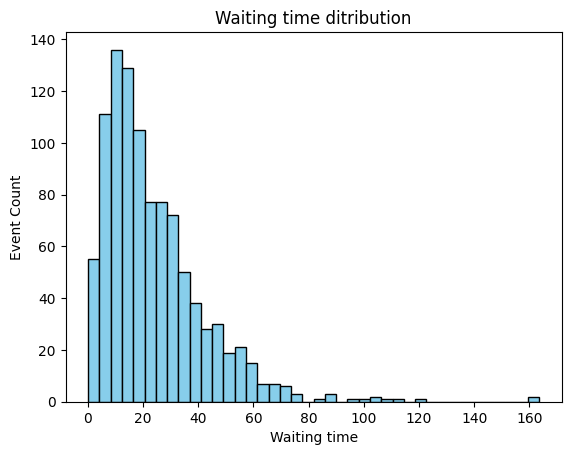

In [3]:
wtime = np.array([])
for i in range(max_photons-1):
    wtime = np.append(wtime,spikes[i+1]-spikes[i])

mean = sum(wtime)/len(wtime)
dev = np.sqrt(sum(wtime**2)/len(wtime) - mean**2)

print("mean waiting time  = ",mean)
print("standard deviation = ",dev)

if dev < 0.9*mean:
    print("likely sub-poissonian")
elif dev > 1.1*mean:
    print("likely super-poissonian")
else:
    print("likely poissonian")
    
plt.hist(wtime, bins=40, color='skyblue', edgecolor='black')
plt.title("Waiting time ditribution")
plt.xlabel("Waiting time")
plt.ylabel("Event Count")
plt.show()


### Calculation of $g^{(2)}(\tau)$

Calculating $g^{(2)}(\tau)$ from the spike train of photons is strait forward.  For a spike train $\{t_{1}, t_{2}, \cdots, t_{N}\}$ of $N$ photons, the number of photons separated by time difference  $\tau$ is given by

$$
n(\tau) = \sum_{i < j} \delta(\tau - t_{j}+t_{i})
$$(eq:pair_counting)

which is proportional to $g^{(2)}(\tau)$.  We must scale $n(\tau)$ so that  $g^{(2)}(\tau)$ is appropriately normalized.  Due to the presence of delta function,  Equation {eq}`eq:pair_counting` is numerically not practical. We usually plot it as a histogram, which shows the number of photons per the bin width $\Delta \tau$. Since $g^{(2)}$ is dimensionless, the scaling functor must cancel $\Delta t$. Recall that $\lim_{\tau\rightarrow\infty} g^{(2)}(\tau) = 1$.  That means there is no correlation at a large $\tau$.  Then, $n(\tau)$ also does not depend on $\tau$.  Now, we evaluate $n$ when there is no correlation. The summation over $i$ generates $N$.   The summation over $j$ counts the average number of photons with $\Delta \tau$, which is $N \Delta \tau / t_\text{max}$ where $t_\text{max}$ is total measurement time.  Thus $n(\infty) \approx N^2 \Delta \tau / t_\text{max}$. Finally we have a properly normalized $g^{(2)}(\tau)$ as
$$
g^{(2)}(\tau) = \frac{n(\tau)}{n(\infty)}  = \frac{n(\tau) t_\text{max}}{N \Delta \tau}
$$

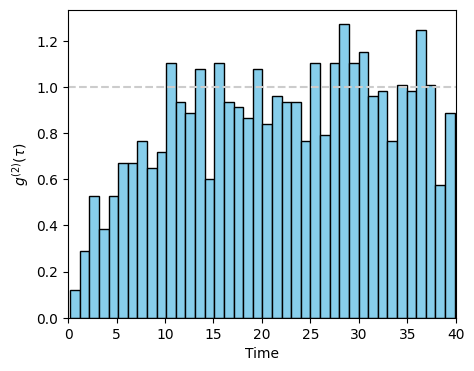

In [4]:

pair_times = np.array([])
i=1

tau_max = 40  # max correlation time

while i < max_photons-20:
    t0 = spikes[i]
    j = i+1
    while  (j > i and j < i+20) :
        t1 = spikes[j]
        if t1-t0 < tau_max:
            pair_times = np.append(pair_times,t1-t0)
        j += 1
    i += 1

nbins = 40
dtau = tau_max/nbins
norm = max_photons**2 /times[k] * dtau 

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(pair_times, weights=np.ones_like(pair_times)/norm,bins=nbins, color='skyblue', edgecolor='black')
ax.axhline(y=1,color = '0.8', linestyle = '--')
plt.xlim([0,tau_max])
plt.xlabel("Time")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.show()

The plot is still noisy due to insufficient number of photons.  However, it is close to the plot obtained from the quantum master equation in the previous section. Anti-bunching is clearly visible. 